<a href="https://colab.research.google.com/github/nevaselvakumar-source/ExtendedEssay/blob/main/trellis_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD THE DATA
# Replace 'your_data.csv' with the actual path to your file.
# We are assigning names to the columns based on your description.
# If your CSV already has a header row, change header=None to header=0
df = pd.read_csv('sample_data/ee_trellis_data.txt', header=None, names=[
    'strain_rate',    # Column 1 (Dependent Y)
    'total_mass',     # Column 2 (Independent X)
    'effective_spin', # Column 3 (Control Row)
    'asymmetry'       # Column 4 (Control Column)
])


Regression Coefficients: Mass(a)=-0.0100, Spin(b)=-1.5968, Intercept(c)=2.4448


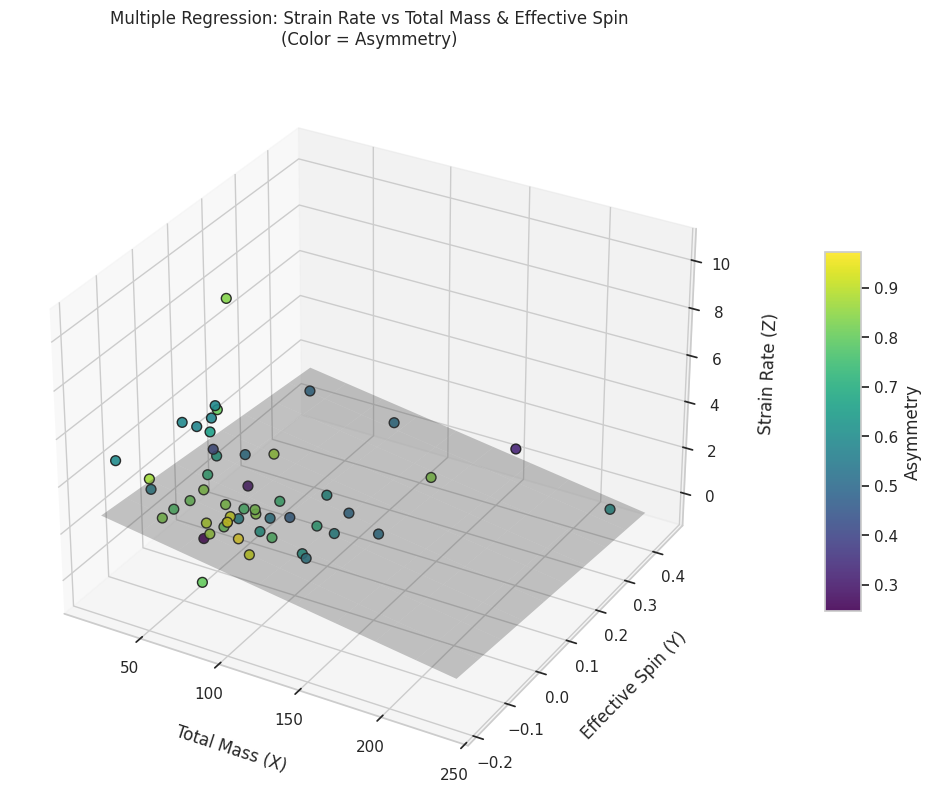

In [23]:
# 2. CALCULATE MULTIPLE REGRESSION PLANE (Z = a*X + b*Y + c)
# We map X = total_mass, Y = effective_spin, Z = strain_rate
X_data = df['total_mass'].values
Y_data = df['effective_spin'].values
Z_data = df['strain_rate'].values

A = np.c_[X_data, Y_data, np.ones(X_data.shape[0])]
coeffs, _, _, _ = np.linalg.lstsq(A, Z_data, rcond=None)
a, b, c = coeffs

print(f"Regression Coefficients: Mass(a)={a:.4f}, Spin(b)={b:.4f}, Intercept(c)={c:.4f}")

# 3. CREATE MESHGRID FOR THE PLANE
X_mesh, Y_mesh = np.meshgrid(
    np.linspace(X_data.min(), X_data.max(), 10),
    np.linspace(Y_data.min(), Y_data.max(), 10)
)
Z_mesh = a * X_mesh + b * Y_mesh + c

# 4. PLOT THE 3D FIGURE
# Using plt.subplots as instructed, specifying the 3d projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": "3d"})

# Plot the regression plane
ax.plot_surface(X_mesh, Y_mesh, Z_mesh, alpha=0.3, color='gray', edgecolor='none')

# Plot the 3D scatter points
scatter = ax.scatter(X_data, Y_data, Z_data,
                     c=df['asymmetry'], cmap='viridis',
                     s=50, edgecolor='k', alpha=0.9)

# Labels & Title
ax.set_xlabel('\nTotal Mass (X)', linespacing=3)
ax.set_ylabel('\nEffective Spin (Y)', linespacing=3)
ax.set_zlabel('\nStrain Rate (Z)', linespacing=3)
ax.set_title('Multiple Regression: Strain Rate vs Total Mass & Effective Spin\n(Color = Asymmetry)', pad=20)

# Add Colorbar for the 4th variable
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Asymmetry')

# Save the plot
plt.tight_layout()
plt.savefig('multiple_regression_3d.png', dpi=300)